In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df=pd.read_csv("Cricket (1).csv")
df

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa0 in position 64: invalid start byte

In [8]:
#this file is utf 8 encoded thats why we have to find its encoding to read it 
import chardet #character encoding detector
with open('Cricket (1).csv','rb') as f:
    result=chardet.detect(f.read(100000))
    print(result)

{'encoding': 'ISO-8859-1', 'confidence': 0.73, 'language': ''}


In [9]:
df=pd.read_csv('Cricket (1).csv',encoding='ISO-8859-1')
df

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200*,44.83,21367,86.23,49,96,20
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15
2,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20
3,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.20,28,68,34
4,DPMD Jayawardene (Asia/SL),1998-2015,448,418,39,12650,144,33.37,16020,78.96,19,77,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,CG Greenidge (WI),1975-1991,128,127,13,5134,133*,45.03,7908,64.92,11,31,3
75,Misbah-ul-Haq (PAK),2002-2015,162,149,31,5122,96*,43.40,6945,73.75,0,42,6
76,PD Collingwood (ENG),2001-2011,197,181,37,5092,120*,35.36,6614,76.98,5,26,7
77,A Symonds (AUS),1998-2009,198,161,33,5088,156,39.75,5504,92.44,6,30,15


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  79 non-null     object 
 1   Span    79 non-null     object 
 2   Mat     79 non-null     int64  
 3   Inns    79 non-null     int64  
 4   NO      79 non-null     int64  
 5   Runs    79 non-null     int64  
 6   HS      79 non-null     object 
 7   Ave     79 non-null     float64
 8   BF      79 non-null     int64  
 9   SR      79 non-null     float64
 10  100     79 non-null     int64  
 11  50      79 non-null     int64  
 12  0       79 non-null     int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 8.2+ KB


In [11]:
# remove asterick from a column value 
df['HS']=df['HS'].str.replace("*","")

In [12]:
df # asterisk is removed frm hs column 1st row 

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200,44.83,21367,86.23,49,96,20
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15
2,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20
3,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.20,28,68,34
4,DPMD Jayawardene (Asia/SL),1998-2015,448,418,39,12650,144,33.37,16020,78.96,19,77,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,CG Greenidge (WI),1975-1991,128,127,13,5134,133,45.03,7908,64.92,11,31,3
75,Misbah-ul-Haq (PAK),2002-2015,162,149,31,5122,96,43.40,6945,73.75,0,42,6
76,PD Collingwood (ENG),2001-2011,197,181,37,5092,120,35.36,6614,76.98,5,26,7
77,A Symonds (AUS),1998-2009,198,161,33,5088,156,39.75,5504,92.44,6,30,15


In [13]:
# now convert this hs column from object to numeric 
df['HS']=df['HS'].astype(int)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  79 non-null     object 
 1   Span    79 non-null     object 
 2   Mat     79 non-null     int64  
 3   Inns    79 non-null     int64  
 4   NO      79 non-null     int64  
 5   Runs    79 non-null     int64  
 6   HS      79 non-null     int64  
 7   Ave     79 non-null     float64
 8   BF      79 non-null     int64  
 9   SR      79 non-null     float64
 10  100     79 non-null     int64  
 11  50      79 non-null     int64  
 12  0       79 non-null     int64  
dtypes: float64(2), int64(9), object(2)
memory usage: 8.2+ KB


In [15]:
df[['Start','End']]=df['Span'].str.split("-",expand=True) 

In [16]:
df.head() # as we have divide or split span column by separating them 

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Start,End
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200,44.83,21367,86.23,49,96,20,1989,2012
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15,2000,2015
2,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20,1995,2012
3,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.20,28,68,34,1989,2011
4,DPMD Jayawardene (Asia/SL),1998-2015,448,418,39,12650,144,33.37,16020,78.96,19,77,28,1998,2015


In [17]:
df['Start']=df['Start'].astype(int)
df['End']=df['End'].astype(int)

In [18]:
# calculating experience of a player using start or end of span
df['exp']=df['End']-df['Start']

In [19]:
df.head()

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Start,End,exp
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200,44.83,21367,86.23,49,96,20,1989,2012,23
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15,2000,2015,15
2,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20,1995,2012,17
3,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.20,28,68,34,1989,2011,22
4,DPMD Jayawardene (Asia/SL),1998-2015,448,418,39,12650,144,33.37,16020,78.96,19,77,28,1998,2015,17


In [20]:
# span , start , end -- drop them as we have already have experience
df.drop(columns=['Span','Start','End'] , inplace=True)

In [21]:
df

,Player,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,exp
0,SR Tendulkar (INDIA),463,452,41,18426,200,44.83,21367,86.23,49,96,20,23
1,KC Sangakkara (Asia/ICC/SL),404,380,41,14234,169,41.98,18048,78.86,25,93,15,15
2,RT Ponting (AUS/ICC),375,365,39,13704,164,42.03,17046,80.39,30,82,20,17
3,ST Jayasuriya (Asia/SL),445,433,18,13430,189,32.36,14725,91.20,28,68,34,22
4,DPMD Jayawardene (Asia/SL),448,418,39,12650,144,33.37,16020,78.96,19,77,28,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,CG Greenidge (WI),128,127,13,5134,133,45.03,7908,64.92,11,31,3,16
75,Misbah-ul-Haq (PAK),162,149,31,5122,96,43.40,6945,73.75,0,42,6,13
76,PD Collingwood (ENG),197,181,37,5092,120,35.36,6614,76.98,5,26,7,10
77,A Symonds (AUS),198,161,33,5088,156,39.75,5504,92.44,6,30,15,11


In [22]:
# check for null values 
df.isna().sum().sum()

np.int64(0)

In [23]:
# check for duplicated values
df.duplicated().sum()

np.int64(0)

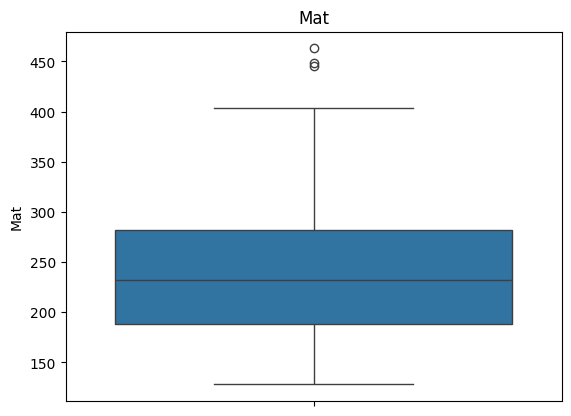

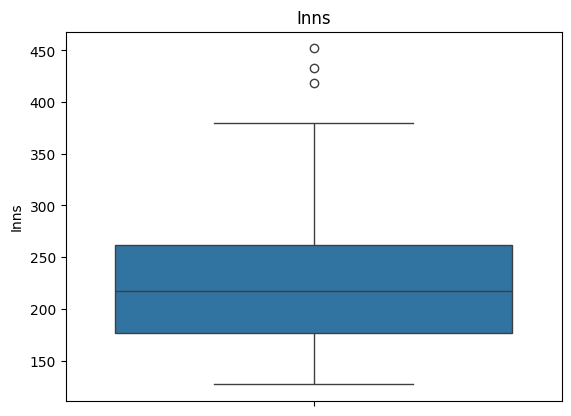

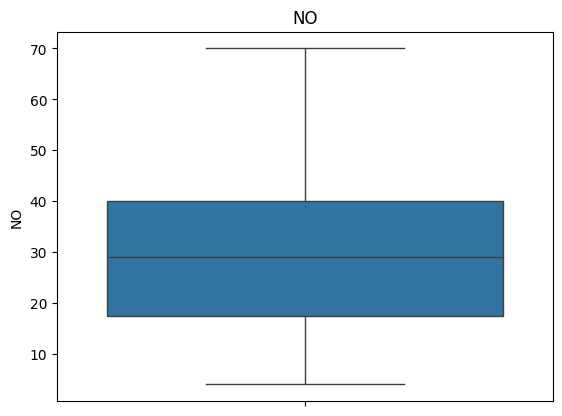

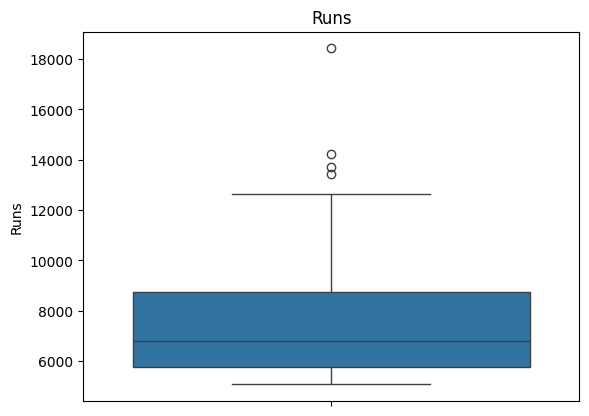

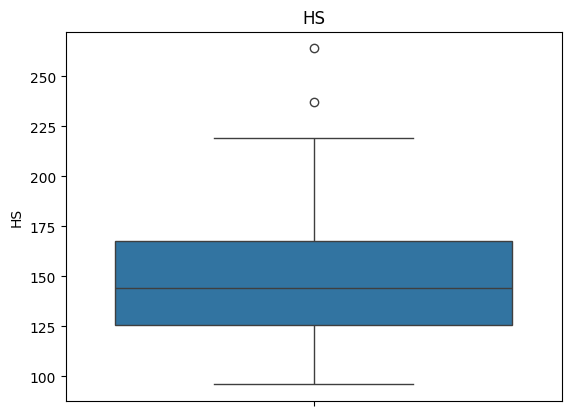

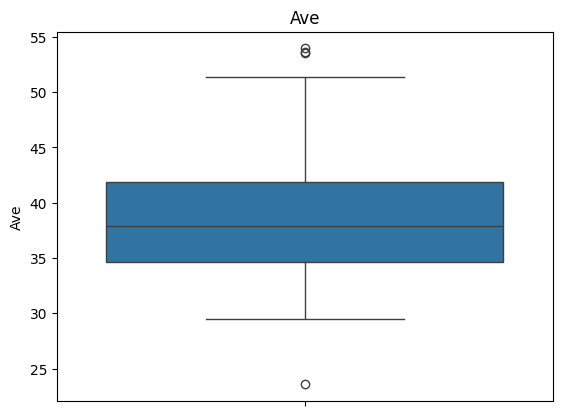

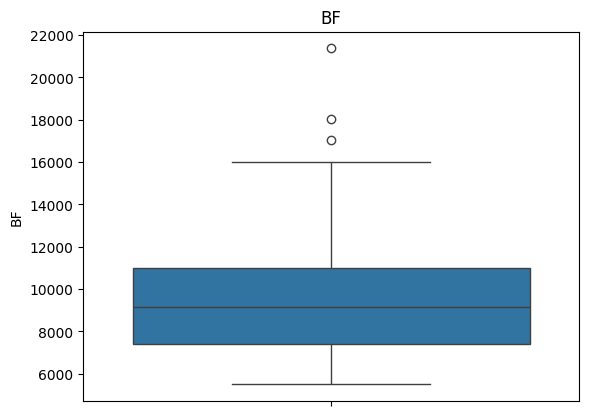

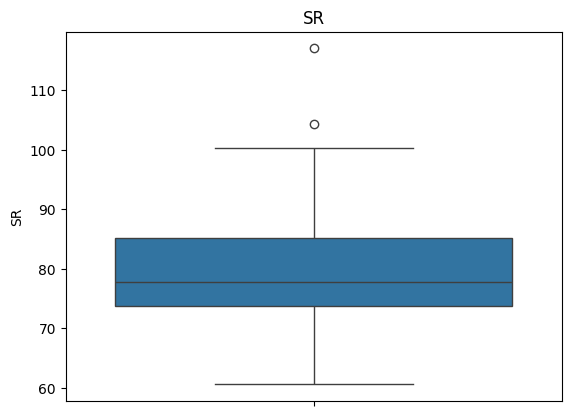

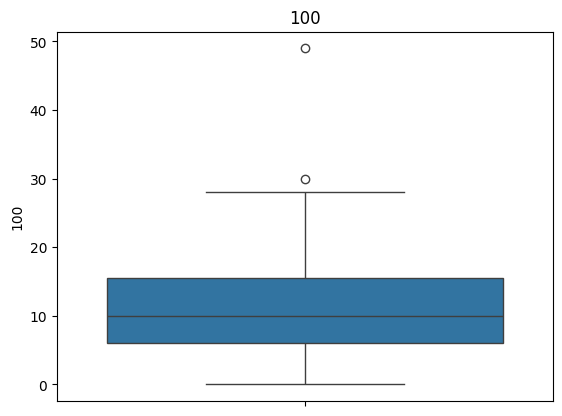

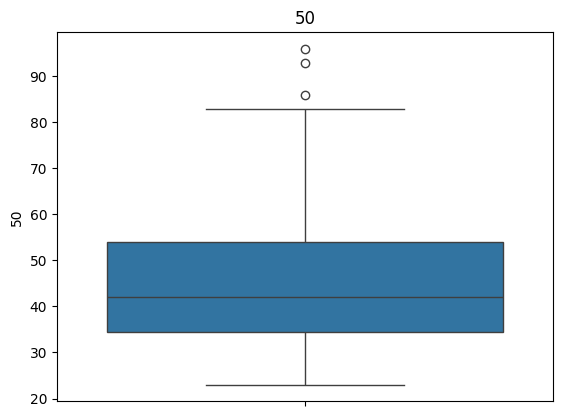

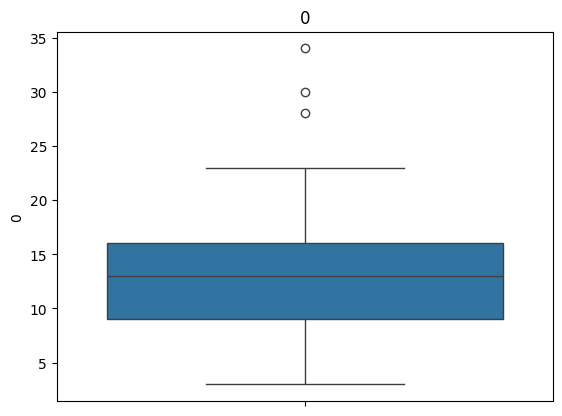

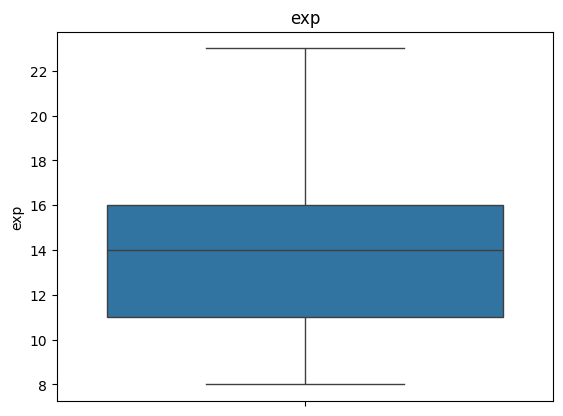

In [24]:
# check for outliers 
for col in df.columns:
    if df[col].dtype!='object':
        sns.boxplot(df[col])
        plt.title(col)
        plt.show()

In [25]:
# we should delete the outliers as they are not the eronous values,
# as there are many players who may achieve extreme values telll us more about the goated players we are going to keep this
# k-means is not robust to the outliers 
#features and columns ??
# just the normal vertical field is your column
# but the column which act as the input for the training of the model they are known  as features

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  79 non-null     object 
 1   Mat     79 non-null     int64  
 2   Inns    79 non-null     int64  
 3   NO      79 non-null     int64  
 4   Runs    79 non-null     int64  
 5   HS      79 non-null     int64  
 6   Ave     79 non-null     float64
 7   BF      79 non-null     int64  
 8   SR      79 non-null     float64
 9   100     79 non-null     int64  
 10  50      79 non-null     int64  
 11  0       79 non-null     int64  
 12  exp     79 non-null     int64  
dtypes: float64(2), int64(10), object(1)
memory usage: 8.2+ KB


In [27]:
# find the feature from above
features=['Mat','Inns','NO','Runs','HS','Ave','BF','SR','100','50','0','exp']

In [28]:
data_= df[features]

In [29]:
# scaling the data 

In [30]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaled_data = scaler.fit_transform(data_)

In [31]:
df_scaled=pd.DataFrame(scaled_data,columns=data_.columns)

In [32]:
df_scaled.head()

,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,exp
0,2.955282,3.169333,0.764963,4.262328,1.632443,1.072294,3.681214,0.703152,4.656726,3.050057,1.145837,2.812787
1,2.155179,2.138915,0.764963,2.609117,0.635224,0.587725,2.635385,-0.044139,1.671888,2.865418,0.296671,0.380938
2,1.761908,1.924245,0.625397,2.400099,0.474382,0.596226,2.319651,0.110997,2.293729,2.188406,1.145837,0.988900
3,2.711183,2.897417,-0.840046,2.292041,1.278591,-1.047909,1.588295,1.207091,2.044992,1.326755,3.523501,2.508806
4,2.751866,2.682747,0.625397,1.984430,-0.168986,-0.876185,1.996354,-0.034000,0.925678,1.880674,2.504502,0.988900


In [33]:
df_scaled['Runs'].mean()

np.float64(1.2648110407122037e-16)

In [34]:
value=np.float64(1.2648110407122037e-16)
print(f"{value: .20f}") # we have converted in decimal so that we can easily understand

 0.00000000000000012648


In [35]:
df_scaled['Runs'].std()

np.float64(1.006389841373865)

In [36]:
# before this std is equal to 1 and mean to 0  as purpose is to bring all the values on the same scale
from sklearn.cluster import KMeans

In [37]:
kmeans=KMeans(n_clusters=3,random_state=7)
kmeans.fit(df_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,7
,copy_x,True
,algorithm,'lloyd'


In [38]:
df_scaled['basic_clusters']=kmeans.labels_
df_scaled # now here we get all the rows divided in the different different clusters

,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,exp,basic_clusters
0,2.955282,3.169333,0.764963,4.262328,1.632443,1.072294,3.681214,0.703152,4.656726,3.050057,1.145837,2.812787,0
1,2.155179,2.138915,0.764963,2.609117,0.635224,0.587725,2.635385,-0.044139,1.671888,2.865418,0.296671,0.380938,0
2,1.761908,1.924245,0.625397,2.400099,0.474382,0.596226,2.319651,0.110997,2.293729,2.188406,1.145837,0.988900,0
3,2.711183,2.897417,-0.840046,2.292041,1.278591,-1.047909,1.588295,1.207091,2.044992,1.326755,3.523501,2.508806,0
4,2.751866,2.682747,0.625397,1.984430,-0.168986,-0.876185,1.996354,-0.034000,0.925678,1.880674,2.504502,0.988900,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,-1.587674,-1.481860,-1.188961,-0.979677,-0.522838,1.106299,-0.559768,-1.457604,-0.069268,-0.950465,-1.741328,0.684919,1
75,-1.126598,-1.167010,0.067133,-0.984410,-1.713068,0.829159,-0.863213,-0.562275,-1.437319,-0.273453,-1.231828,-0.227024,1
76,-0.651961,-0.709047,0.485831,-0.996241,-0.941027,-0.537836,-0.967512,-0.234765,-0.815478,-1.258197,-1.061995,-1.138967,1
77,-0.638400,-0.995274,0.206699,-0.997819,0.217035,0.208570,-1.317278,1.332823,-0.691110,-1.012011,0.296671,-0.834986,1


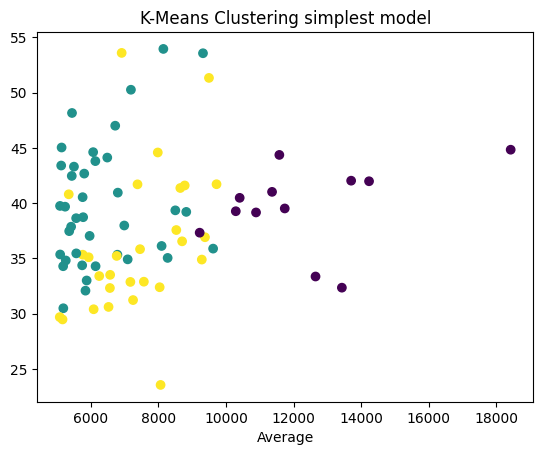

In [39]:
plt.scatter(df['Runs'],df['Ave'],c=df_scaled['basic_clusters'],cmap='viridis')
plt.xlabel('Runs')
plt.xlabel('Average')
plt.title('K-Means Clustering simplest model')
plt.show()

In [40]:
#inertia tells as how closely the points are packed in a cluster , if the inertia value is high it means the points are scattered far away
# if value is low it means points are compact 
# inertia should be as less as possible 
# where we will see a high sudden drop in inertia that value we will use as our no of clusters

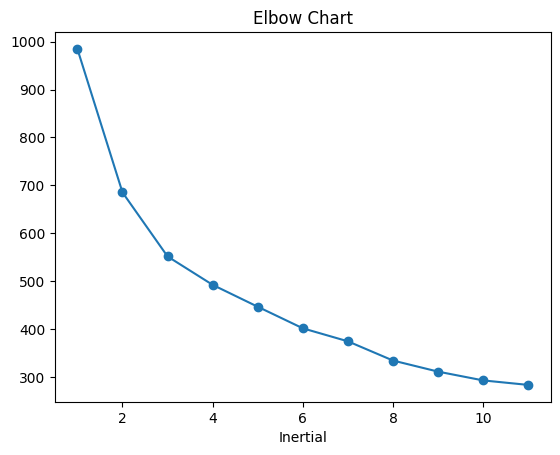

In [41]:
inertia=[]
for k in range(1,12):
    kmeans=KMeans(n_clusters=k,random_state=6)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)
plt.plot(range(1,12),inertia,marker='o')
plt.xlabel('Number Of Clusters')
plt.xlabel('Inertial')
plt.title("Elbow Chart")
plt.show()

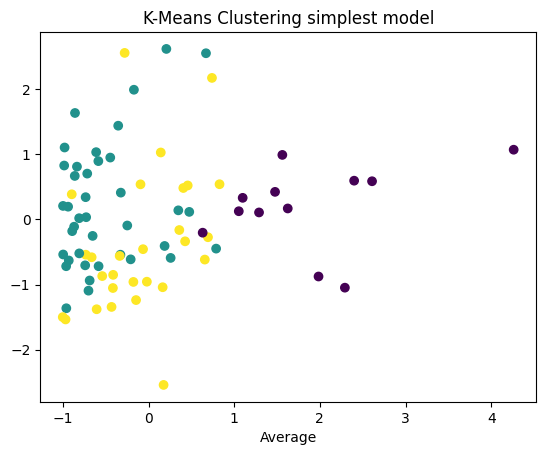

In [42]:
plt.scatter(df_scaled['Runs'],df_scaled['Ave'],c=df_scaled['basic_clusters'],cmap='viridis')
plt.xlabel('Runs')
plt.xlabel('Average')
plt.title('K-Means Clustering simplest model')
plt.show()

In [ ]:
!pip install plotly

In [ ]:
import plotly.express as px   # ✅ correct

In [ ]:
fig = px.scatter_3d(
    df_scaled,
    x='Runs',
    y='Ave',
    z='SR',
    color='basic_clusters',   # ✅ fixed
    title='3D plot for KMeans Clustering'
)
fig.show()

In [ ]:
print(df_scaled.columns)

In [ ]:
# silhoutte score
# distance within the cluster and between the cluster 
# we want within cluster distance to be minimum
# we want cluster distance from each other  to be maximum
#+1= clustering is very gud 
# 0.5 clustering is fine
# 0 - clusters are overlapping
# negative - clustering is not working , totally incorrect

In [ ]:
from sklearn.metrics import silhouette_score
kmeans1=Kmeans(n_clusters=3,n_init=10,random_state=46)
labels=kmean1.fit_predict(df_scaled)
score=silhouette_score(df_scaled,labels)
print("silhouette score:",score)


In [ ]:
from sklearn.metrics import silhouette_score
kmeans1=Kmeans(n_clusters=2,n_init=10,random_state=46)
labels=kmean1.fit_predict(df_scaled)
score=silhouette_score(df_scaled,labels)
print("silhouette score:",score)
